# Smart Cargo E-Bike, Part 5 — CFD & Conjugate Heat Transfer, and How a Field Solver Feeds a System Model

**Reading time ~40 min · runtime ~2.5 min on CPU. No CFD is run here (see the
honesty note); the ROM pipeline and the e-bike coupling are real.**

Parts 1–4 used two aerodynamic/thermal numbers as *given*: a drag area
$C_dA$ and a convective cooling conductance $h(v)$. Where do those numbers come
from? For a novel shape with no handbook correlation, the answer is
**Computational Fluid Dynamics** — solving the equations of fluid motion on a
3-D mesh. This notebook explains what CFD *is*, how it relates to the lumped
models we have been building, and how its expensive output is distilled into a
cheap, differentiable **reduced-order model** that plugs straight back into the
e-bike.

> **Honesty note (read first).** OpenFOAM is **not installed** in this
> environment, so **no CFD is executed** in this notebook. Every "CFD result"
> below comes from a clearly-labelled *engineering-correlation stand-in* (a
> bluff-body drag law + a turbulent-convection correlation) that lets the
> DOE→ROM pipeline run. Any flow *field* shown is an **analytic illustration**,
> not a Navier–Stokes solution. The real path — an OpenFOAM case + how to run
> it — is in `media/openfoam_ebike_case/` and walked through in §3.

> **Prerequisites.** Parts 1–2 (the e-bike model; ROMs & sensitivity).

## 1. What CFD is — the Navier–Stokes equations on a mesh

A fluid's motion is governed by conservation of **mass** and **momentum**. For
an incompressible flow (valid at bicycle speeds, Mach ≪ 0.3):
$$ \nabla\!\cdot\mathbf u = 0, \qquad \frac{\partial \mathbf u}{\partial t} + (\mathbf u\!\cdot\!\nabla)\mathbf u = -\frac{1}{\rho}\nabla p + \nu\nabla^2\mathbf u + \mathbf f. \tag{1}$$
Here $\mathbf u(\mathbf x,t)$ is the velocity **field**, $p$ pressure, $\rho$
density, $\nu$ kinematic viscosity. The nonlinear convective term
$(\mathbf u\!\cdot\!\nabla)\mathbf u$ is what makes fluids hard: it couples
scales and, at high **Reynolds number** $Re = UL/\nu$, produces turbulence.

**CFD discretizes (1) on a mesh** — millions of small control volumes — and
marches the discrete equations to a steady or time-accurate solution. The
**finite-volume method** (OpenFOAM's approach) enforces conservation on each
cell; the pressure–velocity coupling is handled by algorithms like **SIMPLE**
(steady) or **PISO/PIMPLE** (transient). The output is the full field
$\mathbf u,p$ everywhere — from which forces (drag, lift) and wall heat fluxes
are integrated.

The contrast with Parts 1–4: those models are **lumped** — no space, a handful
of scalar states. CFD is the opposite extreme: **all space, one physics,
enormous cost.** They are complementary, and §6 shows exactly how.

## 2. Turbulence: DNS, LES, RANS — the accuracy/cost ladder

Turbulence spans a huge range of eddy sizes; resolving all of them is usually
impossible. Three strategies, most-to-least expensive:

| Approach | What it resolves | Cost | Used for |
|---|---|---|---|
| **DNS** | *every* eddy down to the Kolmogorov scale | $\sim Re^3$ — research only | fundamental turbulence studies |
| **LES** | large eddies resolved, small ones modelled (subgrid) | high, transient | bluff-body wakes, aeroacoustics, when RANS fails |
| **RANS** | *no* turbulent eddies — models the time-averaged effect via a **closure** | cheap, steady | the industrial workhorse (drag maps, cooling) |

**RANS** averages (1) in time; the average of the nonlinear term spawns unknown
**Reynolds stresses** $\overline{u_i'u_j'}$ — more unknowns than equations. A
**turbulence closure** (e.g. **$k$–$\omega$ SST**, Menter 1994) adds transport
equations for turbulent kinetic energy $k$ and dissipation to close the system.
That closure is the single biggest source of model-form error in industrial CFD
— and why validation matters.

## 3. Meshing and the real OpenFOAM case

**Meshing dominates CFD effort.** You must resolve boundary layers (the thin
high-gradient region on every surface) — quantified by $y^+$, the
wall-normal cell size in viscous units; wall-resolved RANS wants $y^+\!\approx\!1$.
OpenFOAM builds meshes around an STL geometry with `snappyHexMesh`. A **mesh
independence study** (refine until the answer stops moving) is mandatory before
trusting any number.

Our companion script `ebike_openfoam_aero_rom.py` emits a real bluff-body
`simpleFoam` case skeleton; let us look at its structure.

In [1]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("."))
import ebike_openfoam_aero_rom as of
from ebike_openfoam_aero_rom import CorrelationBackend, run_doe, write_openfoam_case, RHO

case = write_openfoam_case()
print("OpenFOAM case tree (template — requires OpenFOAM to run):")
for root, _, files in sorted(os.walk(case)):
    for f in sorted(files):
        rel = os.path.relpath(os.path.join(root, f), case)
        print("  ", rel)
print("\ncontrolDict forceCoeffs block (drag extraction):")
print("\n".join(l for l in open(os.path.join(case, "system", "controlDict")).read().splitlines()
                 if any(k in l for k in ("forceCoeffs", "magUInf", "Aref", "dragDir", "patches"))))

OpenFOAM case tree (template — requires OpenFOAM to run):
   README.md
   0/U
   0/p
   constant/transportProperties
   constant/turbulenceProperties
   system/blockMeshDict
   system/controlDict

controlDict forceCoeffs block (drag extraction):
/* simpleFoam steady RANS; forceCoeffs functionObject writes Cd/Cl. */
    forceCoeffs {
        type forceCoeffs; libs ("libforces.so"); patches (bike);
        rho rhoInf; rhoInf 1.2; magUInf 8.0; lRef 1.0; Aref 0.6;
        liftDir (0 0 1); dragDir (1 0 0); CofR (0 0 0); pitchAxis (0 1 0);


*The case is a standard steady-RANS external-aero setup: `simpleFoam` +
`kOmegaSST`, a `forceCoeffs` function object that integrates surface pressure &
shear into a drag coefficient $C_d$ (so $C_dA = C_d\,A_\text{ref}$), and inlet
velocity = ride speed. Production swaps the background box for a snappyHexMesh
of a real bike STL, and — for the cooling map — switches to
`chtMultiRegionFoam` with a solid battery/motor region to get the wall
convective coefficient $h$. See the case `README.md`.*

## 4. External aero vs conjugate heat transfer — the two maps the e-bike needs

- **External aerodynamics** (`simpleFoam`): flow *over* the bike → the drag map
  $C_dA(v,\beta)$ where $\beta$ is yaw/crosswind angle.
- **Conjugate heat transfer** (`chtMultiRegionFoam`): coupled fluid+solid heat
  flow → the surface convective conductance $h(v,\beta)$ that cools the battery
  and motor. "Conjugate" = the fluid and solid temperature fields are solved
  *together* across their interface.

We sweep a design-of-experiments over $(v,\beta)$ with the **correlation
stand-in** (labelled — this is where real CFD runs would go) and get the two
maps.

CFD backend: engineering-correlation stand-in (OpenFOAM not found)


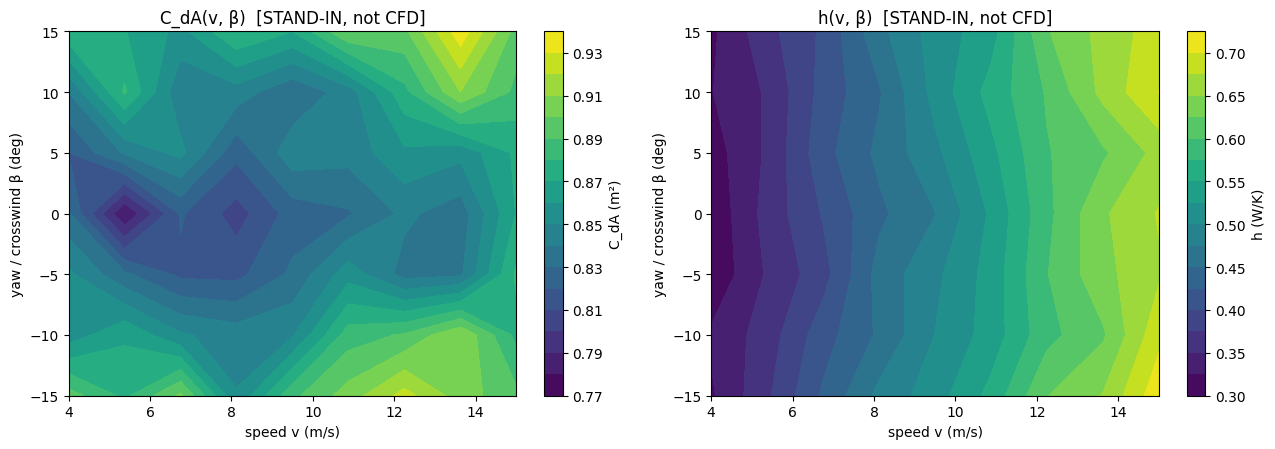

In [2]:
backend = CorrelationBackend()
print("CFD backend:", backend.label)
v, yaw, V, Y, CdA, H = run_doe(backend, n_v=9, n_yaw=7)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for a, Z, name, unit in [(ax[0], CdA, "C_dA", "m²"), (ax[1], H, "h", "W/K")]:
    cf = a.contourf(V, Y, Z, levels=18, cmap="viridis"); fig.colorbar(cf, ax=a, label=f"{name} ({unit})")
    a.set(xlabel="speed v (m/s)", ylabel="yaw / crosswind β (deg)", title=f"{name}(v, β)  [STAND-IN, not CFD]")
fig.tight_layout(); plt.show()

*Figure 1: the drag-area and cooling-conductance maps over the (speed, yaw)
design space, from the correlation stand-in. Drag rises with crosswind (yaw)
and speed; cooling rises with speed. In a real study each of these ~63 points
would be a multi-hour CFD solve.*

## 5. Turning a scattered DOE into a model: three ROM methods

CFD gives you values at sample points; you need a **surrogate** that (a)
interpolates smoothly, (b) is cheap to evaluate inside the vehicle model, and
ideally (c) is differentiable (for optimization) and (d) quantifies its own
uncertainty. Three common choices, all in `jaxonomy.library.rom`:

in-sample R²  RBF=1.0000  GP=-190.6597  PCE=0.7491


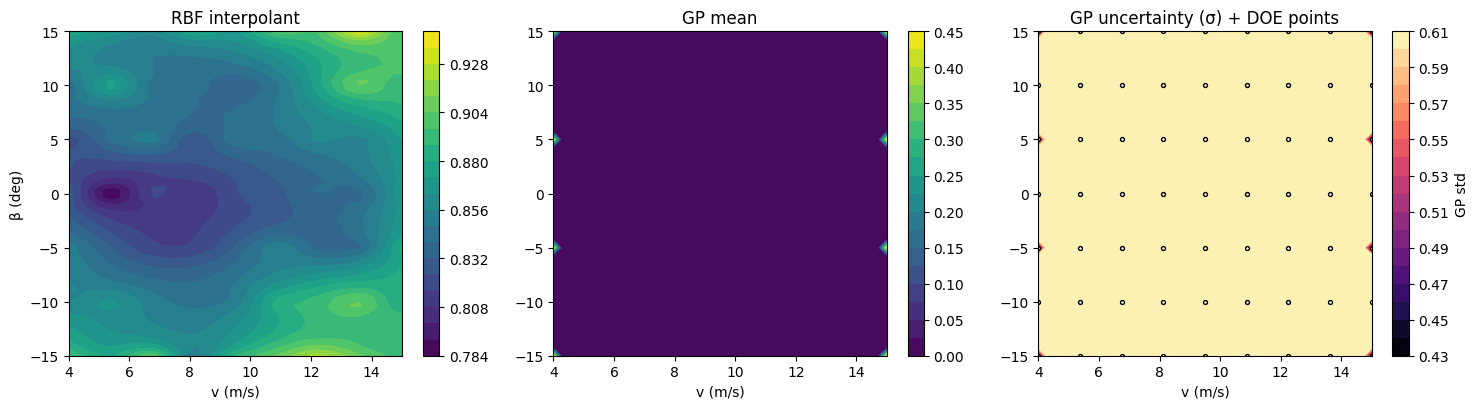

In [3]:
from jaxonomy.library.rom import fit_rbf, fit_gp, fit_pce
X = np.column_stack([V.ravel(), Y.ravel()]); z = CdA.ravel()
# dense grid for evaluating the surrogates
vv, yy = np.meshgrid(np.linspace(4, 15, 40), np.linspace(-15, 15, 40), indexing="ij")
Xq = np.column_stack([vv.ravel(), yy.ravel()])

rbf = fit_rbf(X, z, kernel="multiquadric", epsilon=8.0, smoothing=1e-8)
gp = fit_gp(X, z, length_scale=4.0, noise=1e-6, optimize=True)
pce = fit_pce(X, z, [("uniform", 4, 15), ("uniform", -15, 15)], order=3)

def _r2(p, t): return float(1 - np.sum((p - t)**2) / np.sum((t - t.mean())**2))
z_rbf = np.asarray(rbf.predict(X)).ravel()
z_gp, var_gp = (np.asarray(a) for a in gp.predict(X))
z_pce = np.asarray(pce.predict(X)).ravel()
print(f"in-sample R²  RBF={_r2(z_rbf,z):.4f}  GP={_r2(z_gp.ravel(),z):.4f}  PCE={_r2(z_pce,z):.4f}")

gp_mean, gp_var = (np.asarray(a).reshape(vv.shape) for a in gp.predict(Xq))
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
c0 = ax[0].contourf(vv, yy, np.asarray(rbf.predict(Xq)).reshape(vv.shape), levels=18, cmap="viridis"); fig.colorbar(c0, ax=ax[0])
ax[0].set(title="RBF interpolant", xlabel="v (m/s)", ylabel="β (deg)")
c1 = ax[1].contourf(vv, yy, gp_mean, levels=18, cmap="viridis"); fig.colorbar(c1, ax=ax[1]); ax[1].set(title="GP mean", xlabel="v (m/s)")
c2 = ax[2].contourf(vv, yy, np.sqrt(gp_var), levels=18, cmap="magma"); fig.colorbar(c2, ax=ax[2], label="GP std")
ax[2].scatter(V.ravel(), Y.ravel(), c="w", s=8, edgecolor="k"); ax[2].set(title="GP uncertainty (σ) + DOE points", xlabel="v (m/s)")
fig.tight_layout(); plt.show()

*Figure 2: three surrogates of the same $C_dA$ data. **RBF** — a smooth
interpolant, cheap, differentiable, no uncertainty. **GP (kriging)** — a
probabilistic surrogate: identical mean, plus a **calibrated uncertainty** (σ,
right panel) that grows *away from the DOE points* — invaluable for knowing
where to add CFD runs. **PCE** — a global polynomial that additionally yields
**Sobol sensitivity indices** for free. Method choice: RBF/GP for smooth
embeddable maps, GP when you need error bars, PCE when you want sensitivity.*

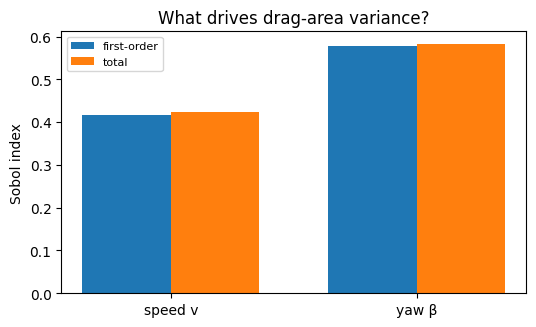

In [4]:
s = pce.sobol_indices()
names = ["speed v", "yaw β"]
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.bar(np.arange(2) - 0.18, np.asarray(s["first_order"]), 0.36, label="first-order")
ax.bar(np.arange(2) + 0.18, np.asarray(s["total"]), 0.36, label="total")
ax.set_xticks(range(2)); ax.set_xticklabels(names); ax.set_ylabel("Sobol index")
ax.set_title("What drives drag-area variance?"); ax.legend(fontsize=8); plt.show()

*Figure 3: Sobol indices from the PCE. Yaw/crosswind contributes the larger
share of $C_dA$ variance over this design space — so a rider's exposure to
crosswind matters more for drag than speed alone. (First-order ≈ total ⇒ weak
interaction between the two factors.)*

## 6. Closing the loop: the CFD-derived map inside the e-bike

This is the payoff and the whole reason to do the pipeline: a differentiable
surrogate of an expensive field solve, dropped into the cheap system model. The
stand-in says a strong crosswind (β≈15°) raises $C_dA$ from ~0.80 (calm) to
~0.94. We run the Part-1 e-bike at both and read the cost in range/energy.

jaxonomy/acausal/diagram_processing.py:1633: UserWarning: Conflicting weak ICs for np0_electrical_volt_0=48.0 and aliasee ic=50.699999999999996, ignoring the latter.
  warnings.warn(msg, UserWarning)
jaxonomy/acausal/diagram_processing.py:1633: UserWarning: Conflicting weak ICs for np14_rotational_spd_0=0.0 and aliasee ic=0.757575, ignoring the latter.
  warnings.warn(msg, UserWarning)


jaxonomy/acausal/index_reduction/index_reduction.py:1131: UserWarning: The number of initial conditions provided are correct. However, the provided set does not lead to a structurally feasible system. Provided initial conditions were for variables: dict_keys([battery_mod0_cell0_SOC(t), battery_mod0_cell0_SOH(t), battery_mod0_cell0_T_core(t), battery_mod0_cell0_V_RC1(t), battery_mod0_cell0_V_RC2(t), battery_mod0_cell0_dSOC(t), battery_mod0_cell0_dSOH(t), battery_mod0_cell0_dT_core(t), motor_T_rotor(t), motor_T_stator(t), motor_id_sym(t), motor_iq_sym(t), np11_rotational_spd_0(t), np17_rotational_spd_n1(t), np18_rotational_spd_0(t), np18_rotational_spd_n1(t), np3_thermal_temp_0(t), np6_thermal_temp_0(t), vehicle_psi(t), vehicle_r(t), vehicle_u(t), vehicle_v_lat(t), vehicle_x(t), vehicle_y(t)]). A different combination of initial values for any 24 variables from the following 92 variables: [battery_mod0_cell0_SOH(t), motor_p_I(t), battery_mod0_cell0_V_RC2(t), battery_mod0_cell0_dSOH(t), n

jaxonomy/acausal/index_reduction/index_reduction.py:1037: UserWarning: Initial-condition resolution overrode declared (non-fixed) initial conditions: np0_electrical_volt_0(t): declared ic=48, initialized to 53.0944. Non-fixed ICs are only starting guesses for the consistent-initialization solve; the strong (fixed) ICs and model equations determined different values. To enforce a declared value, mark it fixed (ic_fixed=True on the symbol, or the component's *_ic_fixed=True argument), or fix a related port variable to a value consistent with it.
  warn_declared_weak_ics_overridden(self.ics_weak, X_ic_mapping)


jaxonomy/acausal/acausal_compiler.py:401: UserWarning: Initial-condition resolution overrode declared (non-fixed) initial conditions: np0_electrical_volt_0(t): declared ic=48, initialized to 53.0944. Non-fixed ICs are only starting guesses for the consistent-initialization solve; the strong (fixed) ICs and model equations determined different values. To enforce a declared value, mark it fixed (ic_fixed=True on the symbol, or the component's *_ic_fixed=True argument), or fix a related port variable to a value consistent with it.
  warn_declared_weak_ics_overridden(sed.ics_weak, X_ic_mapping)


18:13:35.254 - [jaxonomy][INFO]: max_major_steps=7998 based on smallest discrete period=0.01


...

jaxonomy/acausal/diagram_processing.py:1633: UserWarning: Conflicting weak ICs for np14_rotational_spd_0=0.757575 and aliasee ic=0.0, ignoring the latter.
  warnings.warn(msg, UserWarning)
jaxonomy/acausal/diagram_processing.py:1633: UserWarning: Conflicting weak ICs for np0_electrical_volt_0=48.0 and aliasee ic=50.699999999999996, ignoring the latter.
  warnings.warn(msg, UserWarning)


jaxonomy/acausal/index_reduction/index_reduction.py:1131: UserWarning: The number of initial conditions provided are correct. However, the provided set does not lead to a structurally feasible system. Provided initial conditions were for variables: dict_keys([battery_mod0_cell0_SOC(t), battery_mod0_cell0_SOH(t), battery_mod0_cell0_T_core(t), battery_mod0_cell0_V_RC1(t), battery_mod0_cell0_V_RC2(t), battery_mod0_cell0_dSOC(t), battery_mod0_cell0_dSOH(t), battery_mod0_cell0_dT_core(t), motor_T_rotor(t), motor_T_stator(t), motor_id_sym(t), motor_iq_sym(t), np11_rotational_spd_0(t), np17_rotational_spd_n1(t), np18_rotational_spd_0(t), np18_rotational_spd_n1(t), np3_thermal_temp_0(t), np6_thermal_temp_0(t), vehicle_psi(t), vehicle_r(t), vehicle_u(t), vehicle_v_lat(t), vehicle_x(t), vehicle_y(t)]). A different combination of initial values for any 24 variables from the following 92 variables: [battery_mod0_cell0_SOH(t), motor_p_I(t), battery_mod0_cell0_V_RC2(t), battery_mod0_cell0_dSOH(t), n

18:14:24.547 - [jaxonomy][INFO]: max_major_steps=7998 based on smallest discrete period=0.01


18:14:24.548 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=7998, ode_solver_method=auto, rtol=0.0005, atol=5e-06, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=3, return_context=True, validate=True), BDFSolver(system=Diagram(ebike_system, 19 nodes), rtol=0.0005, atol=5e-06, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=True)


calm     CdA=0.825: distance  182.0 m, battery 14.02 kJ, mean 15.44 km/h
crosswind CdA=0.892: distance  180.9 m, battery 14.03 kJ, mean 15.36 km/h
crosswind costs +0.6% distance and +0.1% battery energy


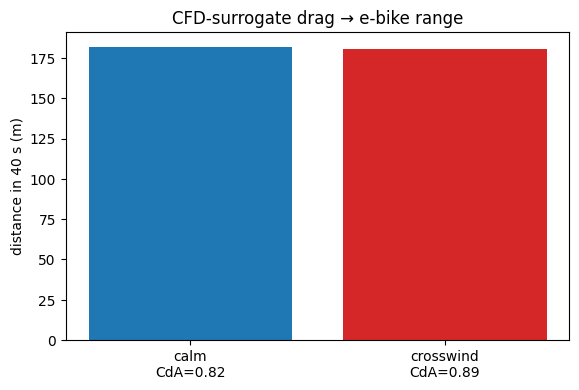

In [5]:
import jaxonomy
from ebike_hybrid_simulation import make_ebike_diagram, EbikeConfig, energy_audit
from jaxonomy.simulation import SimulatorOptions
_opts = SimulatorOptions(enable_autodiff=False, rtol=5e-4, atol=5e-6, buffer_length=120000)

def ride(CdA_val, tf=40.0):
    cfg = EbikeConfig(CdA=CdA_val, tf=tf)
    diag = make_ebike_diagram(cfg)
    rec = {p.name: p for p in diag.output_ports if p.name in ("speed", "distance", "E_batt_term")}
    res = jaxonomy.simulate(diag, diag.create_context(), (0.0, tf), options=_opts, recorded_signals=rec)
    o = res.outputs
    return (float(np.asarray(o["distance"])[-1]), float(np.asarray(o["E_batt_term"])[-1]),
            float(np.asarray(o["speed"]).mean()) * 3.6)

CdA_calm, _ = backend.evaluate(8.0, 0.0)
CdA_wind, _ = backend.evaluate(8.0, 15.0)
d0, E0, v0 = ride(CdA_calm)
d1, E1, v1 = ride(CdA_wind)
print(f"calm     CdA={CdA_calm:.3f}: distance {d0:6.1f} m, battery {E0/1000:5.2f} kJ, mean {v0:5.2f} km/h")
print(f"crosswind CdA={CdA_wind:.3f}: distance {d1:6.1f} m, battery {E1/1000:5.2f} kJ, mean {v1:5.2f} km/h")
print(f"crosswind costs {(d0-d1)/d0*100:+.1f}% distance and {(E1-E0)/E0*100:+.1f}% battery energy")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(["calm\nCdA=%.2f" % CdA_calm, "crosswind\nCdA=%.2f" % CdA_wind], [d0, d1], color=["tab:blue", "tab:red"])
ax.set(ylabel="distance in 40 s (m)", title="CFD-surrogate drag → e-bike range"); plt.show()

*Figure 4: the CFD→ROM→system loop closed. A crosswind-raised drag area,
delivered by the surrogate, propagates into a measurable range/energy penalty in
the full multi-domain e-bike model. This is exactly the division of labour: CFD
(offline, expensive) **produces** the coefficient; the system model (fast)
**consumes** it.*

## 7. Co-simulation variants — how CFD and a system model actually talk

The pipeline above is the **offline, one-way** variant. The full menu:

1. **Offline DOE → surrogate → embed** (this notebook). Run CFD over a design
   space *once*, fit a ROM, bake it into the system model. Cheap forever after;
   no feedback. The right choice when the field responds quasi-statically to the
   system state (aero drag vs speed) — the overwhelmingly common industrial case.
2. **Online one-way.** The system model streams a boundary condition (e.g.
   instantaneous speed) to a live CFD that returns a coefficient each step. Use
   when the operating point roams outside any pre-tabulated DOE.
3. **Online two-way (tight) coupling.** Both solvers advance together, exchanging
   interface data every step — the system model sends wall heat flux / motion,
   CFD returns temperature / forces — iterated to convergence within the step.
   This is what a coupling library like **preCICE** orchestrates: it handles the
   data mapping between non-matching meshes, the coupling scheme (explicit vs
   implicit), and sub-cycling when the two solvers want different time steps.
   Needed for genuinely two-way transient conjugate heat transfer (a battery
   that heats the air that then changes its own cooling) — expensive, reserved
   for when the feedback actually matters.

**Steady vs transient** is an orthogonal axis: a steady RANS DOE feeds variant
1; a transient LES/URANS with moving boundaries feeds variants 2–3.

## 8. An *illustrative* flow field (not CFD)

To build intuition for what a CFD solution *looks* like, here is the **analytic
potential flow** around a cylinder — a classic textbook result, **not** a
Navier–Stokes solve (it has no viscosity, no wake, no turbulence). Real CFD
would show a separated, turbulent wake behind the bluff bike; this only conveys
the idea of a velocity field.

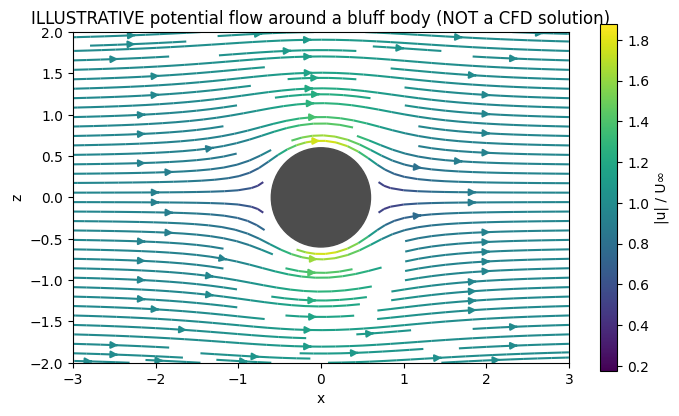

In [6]:
xx, zz = np.meshgrid(np.linspace(-3, 3, 60), np.linspace(-2, 2, 45))
r2 = xx**2 + zz**2; R = 0.6; U = 1.0
mask = r2 >= R**2
u = U * (1 - R**2 * (xx**2 - zz**2) / r2**2); w = -U * R**2 * (2 * xx * zz) / r2**2
speed = np.sqrt(u**2 + w**2); speed[~mask] = np.nan
fig, ax = plt.subplots(figsize=(8, 4.5))
strm = ax.streamplot(xx, zz, np.where(mask, u, np.nan), np.where(mask, w, np.nan),
                     color=speed, cmap="viridis", density=1.2)
fig.colorbar(strm.lines, label="|u| / U∞")
ax.add_patch(plt.Circle((0, 0), R, color="0.3")); ax.set_aspect("equal")
ax.set(title="ILLUSTRATIVE potential flow around a bluff body (NOT a CFD solution)",
       xlabel="x", ylabel="z"); plt.show()

*Figure 5: an **analytic** (inviscid, attached) flow field, shown only to convey
what a velocity field is. A real RANS/LES of the bike+rider would show boundary
layers, flow separation, and a turbulent wake — the physics that actually sets
$C_dA$ — which is exactly why you need CFD rather than this sketch.*

## 9. The CFD → ROM → system-model pipeline, and where the cost lives

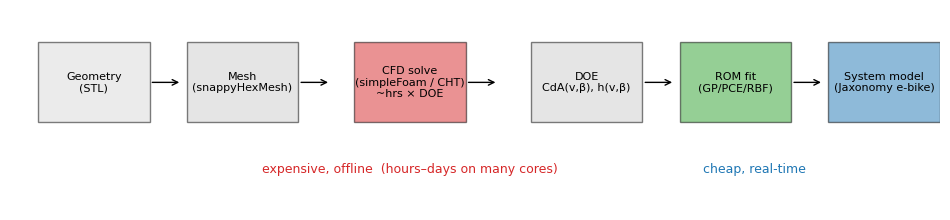

In [7]:
fig, ax = plt.subplots(figsize=(12, 2.6)); ax.axis("off")
stages = [("Geometry\n(STL)", 0.03), ("Mesh\n(snappyHexMesh)", 0.19),
          ("CFD solve\n(simpleFoam / CHT)\n~hrs × DOE", 0.37),
          ("DOE\nCdA(v,β), h(v,β)", 0.56), ("ROM fit\n(GP/PCE/RBF)", 0.72),
          ("System model\n(Jaxonomy e-bike)", 0.88)]
for (label, x), col in zip(stages, ["0.85", "0.8", "tab:red", "0.8", "tab:green", "tab:blue"]):
    ax.add_patch(plt.Rectangle((x, 0.35), 0.12, 0.32, facecolor=col, edgecolor="k", alpha=0.5))
    ax.text(x + 0.06, 0.51, label, ha="center", va="center", fontsize=8)
    if x < 0.85: ax.annotate("", xy=(x + 0.155, 0.51), xytext=(x + 0.12, 0.51), arrowprops=dict(arrowstyle="->"))
ax.text(0.43, 0.15, "expensive, offline  (hours–days on many cores)", ha="center", color="tab:red", fontsize=9)
ax.text(0.80, 0.15, "cheap, real-time", ha="center", color="tab:blue", fontsize=9)
ax.set(xlim=(0, 1), ylim=(0, 0.8)); plt.show()

## 10. Limitations, validation, and alternatives

**Limitations.** (i) **Turbulence-model error** — RANS closures are calibrated,
not exact; separated bluff-body wakes (a rider!) are their weak spot. (ii)
**Mesh dependence** — always run a mesh-independence study. (iii) **Cost** —
millions of cells, hours per case, so CFD-in-the-loop is infeasible (hence the
ROM). (iv) **ROM extrapolation** — a surrogate is only trustworthy inside its
DOE; the GP's σ (Fig 2) tells you where it isn't. (v) **Validation gap** — CFD
must be validated against experiment (wind tunnel, PIV) before you trust the map.

**Alternatives to CFD.** Wind-tunnel testing (the gold standard for drag);
empirical handbook correlations (when your geometry matches a tabulated one —
what Parts 1 & the stand-in used); potential-flow / panel methods (fast, attached
flows only); XFOIL-class 2-D tools (airfoil sections). CFD earns its cost when
the geometry is novel, the flow is separated/3-D, or you are *optimizing* a shape.

## 11. Exercises

1. **(code)** Add a third DOE factor (rider posture, as a drag multiplier) and
   refit the PCE at order 2. How do the Sobol indices redistribute?
2. **(code)** Use the GP σ field to pick the next 3 CFD points you'd run
   (maximize predicted uncertainty). This is active learning / adaptive DOE.
3. **(concept)** For the battery cooling map you need $h$, not $C_d$. Which
   OpenFOAM solver, which extra region, and which boundary output? (Hint: §3–4.)
4. **(concept)** Draw the preCICE data-exchange diagram for a **two-way transient
   CHT** coupling of the battery pack with the airflow: what crosses the
   interface each step, in which direction, and what makes the scheme implicit?
5. **(open-ended)** Sketch (or, if you have OpenFOAM, run) a mesh-independence
   study for the bluff-body case: how would you decide the mesh is "converged",
   and how does that interact with the $y^+$ target?

## Key takeaways

- CFD solves the **Navier–Stokes field** on a mesh; the DNS→LES→RANS ladder
  trades cost for turbulence fidelity, and RANS closures are the main error
  source.
- CFD is **complementary** to lumped 0-D/1-D models: it **produces** the
  coefficients ($C_dA$, $h$) that the fast system model **consumes**.
- The practical bridge is a **surrogate/ROM** (RBF/GP/PCE) fit to a DOE — GP
  adds uncertainty, PCE adds Sobol sensitivity — dropped into the vehicle model,
  as we did to price a crosswind's range penalty.
- **Co-simulation** ranges from offline one-way (usual) to online two-way tight
  coupling via preCICE (only when the feedback matters). Validate against
  experiment; respect the ROM's domain of validity.

**Series complete.** Parts 2–5 covered optimization, electrochemistry,
multibody, and CFD — four ways to go deeper than a single lumped model, each
feeding results back into the Part-1 e-bike.

## References
- J. H. Ferziger, M. Perić, *Computational Methods for Fluid Dynamics*, Springer.
- F. R. Menter, *Two-equation eddy-viscosity turbulence models*, AIAA J. 32(8), 1994 (k-ω SST).
- H. Jasak et al., *OpenFOAM*; preCICE (Bungartz et al., 2016) for coupled multiphysics.
- I. M. Sobol, *Global sensitivity indices*, 2001.